# D2.2-3: Jupyter Notebook for Dask Usage

## Overview
This notebook demonstrates scalable geospatial data processing using:
- STAC (data discovery)
- Zarr (cloud-native storage)
- Xarray (labeled data structures)
- Dask (parallel + distributed computation)

## Objectives
- Process large Earth Observation datasets lazily
- Scale from local to distributed environments
- Benchmark Dask performance
- Provide reproducible and modular workflows


## Environment Setup

This notebook requires the following Python packages:

- xarray
- dask[distributed]
- zarr
- fsspe
- pystac-client
- matplotlib

### Notes

- For local execution, these can be installed via pip or conda.
- For distributed execution (e.g. EODC Dask Gateway), dependencies must be available in the worker environment.
- Installing packages within the notebook does not affect remote workers.


In [ ]:
# Optional: install dependencies (for local environments only)
# Uncomment if needed

# !pip install xarray dask[distributed] zarr fsspec pystac-client matplotlib

## 1. Set Up Dask Cluster

This notebook supports two execution modes:

### Local Mode
- Uses `LocalCluster`
- Suitable for development and small-scale testing

### eodc Cluster Mode
- Uses `EODCDaskGateway`
- Enables distributed processing on eodc infrastructure
- Suitable for large-scale production workloads
- Requires and eodc account ([https://eodc.eu/register](https://eodc.eu/register))

Switch mode by setting:

```python
CLUSTER_TYPE = "local"  # or "eodc"

In [ ]:
CLUSTER_TYPE = "local"  

if CLUSTER_TYPE == "local":
    from dask.distributed import Client, LocalCluster
    
    cluster = LocalCluster(
        n_workers=3,
        threads_per_worker=1,
        dashboard_address=":0"
    )
    client = Client(cluster)

elif CLUSTER_TYPE == "eodc":
    import os
    import certifi
    os.environ["SSL_CERT_FILE"] = certifi.where()
    
    from eodc.dask import EODCDaskGateway
    
    gateway = EODCDaskGateway(username="user@eodc.eu")

    options = gateway.cluster_options()
    options.image = "ghcr.io/eodcgmbh/cluster_image:latest"

    cluster = gateway.new_cluster(cluster_options=options)

    client = cluster.get_client()
    cluster.scale(3)

client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:38877/status,
Dashboard: http://127.0.0.1:38877/status,Workers: 3
Total threads: 3,Total memory: 14.96 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43315,Workers: 0
Dashboard: http://127.0.0.1:38877/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36113,Total threads: 1
Dashboard: http://127.0.0.1:37663/status,Memory: 4.99 GiB
Nanny: tcp://127.0.0.1:44899,


## 2. Discover Dataset via STAC

In [2]:
import pystac_client

catalog = pystac_client.Client.open('https://stac.eodc.eu/api/v1')
collection = catalog.get_collection('SENTINEL5P_DAILY_AUT')
store_url = collection.get_single_link('store').href
store_url

'http://data.eodc.eu/collections/SENTINEL5P/s5p-daily-aut-10km.zarr'

## 3. Load Zarr Data with Xarray (Dask-backed)

In [3]:
import xarray as xr

ds = xr.open_zarr(store_url, group='CO', consolidated=True)
ds

<xarray.Dataset> Size: 743MB
Dimensions:                        (time: 2812, qa_threshold: 3, y: 91, x: 121)
Coordinates:
  * time                           (time) datetime64[ns] 22kB 2018-07-05 ... ...
  * qa_threshold                   (qa_threshold) float64 24B 0.0 0.5 0.75
  * y                              (y) float64 728B 2.029e+06 ... 1.129e+06
  * x                              (x) float64 968B 4.437e+06 ... 5.637e+06
    spatial_ref                    int64 8B ...
Data variables:
    carbonmonoxide_total_column    (time, qa_threshold, y, x) float32 372MB dask.array<chunksize=(30, 1, 91, 121), meta=np.ndarray>
    carbonmonoxide_total_column_n  (time, qa_threshold, y, x) int32 372MB dask.array<chunksize=(30, 1, 91, 121), meta=np.ndarray>

## 4. Verify Dask Usage

In [4]:
carbon = ds['carbonmonoxide_total_column'].sel(qa_threshold=0.5)

print(type(carbon.data))
print('Chunks:', carbon.chunks)
print('Dashboard:', client.dashboard_link)

<class 'dask.array.core.Array'>
Chunks: ((30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 22), (91,), (121,))
Dashboard: http://127.0.0.1:38877/status


## 5. Scalable Processing with Dask

In [5]:
carbon = carbon.sel(time=slice('2019-01-01','2024-12-31'))
spatial_mean = carbon.mean(dim=('y','x'))
spatial_mean

<xarray.DataArray 'carbonmonoxide_total_column' (time: 2181)> Size: 9kB
dask.array<mean_agg-aggregate, shape=(2181,), dtype=float32, chunksize=(30,), chunktype=numpy.ndarray>
Coordinates:
  * time          (time) datetime64[ns] 17kB 2019-01-01 ... 2024-12-31
    qa_threshold  float64 8B 0.5
    spatial_ref   int64 8B ...
Attributes:
    multiplication_factor_to_convert_to_molecules_percm2:  6.022140853952394e+19
    long_name:                                             Vertically integra...
    units:                                                 mol m-2
    cell_methods:                                          time: mean
    comment:                                               Daily mean derived...
    grid_mapping:                                          spatial_ref

## 6. Trigger Computation

In [6]:
result = spatial_mean.compute()
result

<xarray.DataArray 'carbonmonoxide_total_column' (time: 2181)> Size: 9kB
array([0.03205828, 0.03118094, 0.03256853, ..., 0.03149405, 0.03244211,
       0.03247518], shape=(2181,), dtype=float32)
Coordinates:
  * time          (time) datetime64[ns] 17kB 2019-01-01 ... 2024-12-31
    qa_threshold  float64 8B 0.5
    spatial_ref   int64 8B 0
Attributes:
    multiplication_factor_to_convert_to_molecules_percm2:  6.022140853952394e+19
    long_name:                                             Vertically integra...
    units:                                                 mol m-2
    cell_methods:                                          time: mean
    comment:                                               Daily mean derived...
    grid_mapping:                                          spatial_ref

## 7. Advanced Performance Benchmark

This section evaluates Dask performance using increasingly complex workloads:

### Benchmarks included:
1. Baseline mean computation
2. Rolling window aggregation (temporal complexity)
3. GroupBy aggregation (parallel workload splitting)
4. Multi-variable processing (realistic workflow)
5. Custom function execution (advanced analytics)
6. Rechunking stress test (data movement cost)
7. Scaling test (workers vs runtime)

These experiments demonstrate how Dask:
- scales with compute resources
- handles large datasets efficiently
- enables complex workflows on chunked data

In [7]:
import time

def benchmark(name, func):
    start = time.time()
    result = func().compute()
    duration = time.time() - start
    print(f"{name:<30} {duration:.2f} sec")
    return duration

In [8]:
import numpy as np

results = {}

carbon = carbon.where(np.isfinite(carbon))
carbon = carbon.dropna(dim="time", how="all")

results["baseline"] = benchmark(
    "Baseline mean",
    lambda: carbon.mean(dim=("y", "x"), skipna=True)
)

results["rolling"] = benchmark(
    "Rolling mean (7d)",
    lambda: carbon.rolling(time=7, min_periods=3).mean().mean(dim=("y", "x"), skipna=True)
)

results["groupby"] = benchmark(
    "GroupBy month",
    lambda: carbon.groupby("time.month").mean(skipna=True)
)

rechunked = carbon.chunk({"time": 120})

results["rechunking"] = benchmark(
    "Rechunk + mean",
    lambda: rechunked.mean(dim=("y", "x"), skipna=True)
)

def custom_func(x):
    return np.nanmean(x) * np.nanstd(x, ddof=0)

custom = xr.apply_ufunc(
    custom_func,
    carbon,
    input_core_dims=[["y", "x"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
)

results["custom"] = benchmark(
    "Custom function",
    lambda: custom
)

Baseline mean                  2.17 sec
Rolling mean (7d)              9.36 sec
GroupBy month                  3.22 sec
Rechunk + mean                 2.30 sec
Custom function                2.25 sec


In [9]:
variables = ["CO", "NO2", "O3"]

def multi_variable():
    outputs = []
    for var in variables:
        ds_var = xr.open_zarr(store_url, group=var, consolidated=True)
        data = ds_var.to_array().squeeze()
        data = data.sel(qa_threshold=0.5)
        data = data.sel(time=slice("2023", "2024"))
        outputs.append(data.mean(dim=("y", "x"), skipna=True))

    return xr.concat(outputs, dim="variable", join="outer")

results["multi_variable"] = benchmark(
    "Multi-variable EO",
    multi_variable
)

Multi-variable EO              7.32 sec


In [10]:
print("\nTesting persist() optimization...")

carbon_cached = carbon.persist()

results["persist_1"] = benchmark(
    "Persisted mean 1",
    lambda: carbon_cached.mean(dim=("y", "x"), skipna=True)
)

results["persist_2"] = benchmark(
    "Persisted mean 2",
    lambda: carbon_cached.std(dim=("y", "x"), skipna=True)
)


Testing persist() optimization...
Persisted mean 1               2.67 sec
Persisted mean 2               0.65 sec


In [11]:
scaling_results = {}

for workers in [1, 2, 3]:
    print(f"\n--- Scaling test: {workers} workers ---")

    if CLUSTER_TYPE == "eodc":
        cluster.scale(workers)
    else:
        from dask.distributed import Client, LocalCluster
        cluster = LocalCluster(n_workers=workers, threads_per_worker=1, dashboard_address=":0")
        client = Client(cluster)

    time.sleep(2)

    start = time.time()
    carbon.rolling(time=7).mean().mean(dim=("y", "x")).compute()
    duration = time.time() - start

    scaling_results[workers] = duration
    print(f"{workers} workers → {duration:.2f} sec")


--- Scaling test: 1 workers ---
1 workers → 20.79 sec

--- Scaling test: 2 workers ---
2 workers → 13.64 sec

--- Scaling test: 3 workers ---
3 workers → 10.69 sec


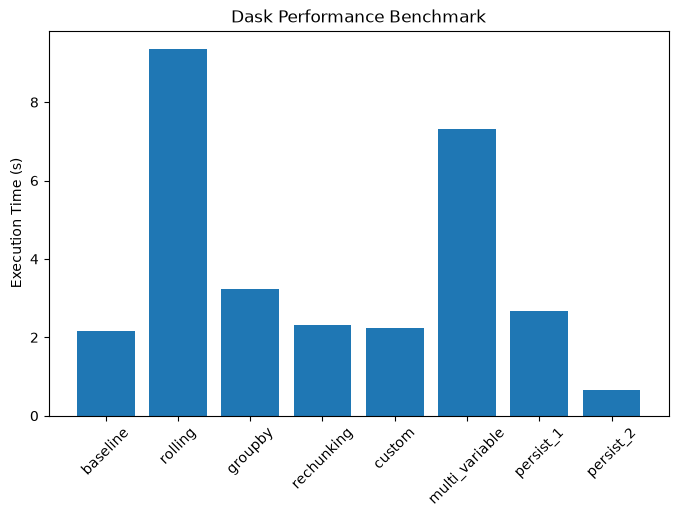

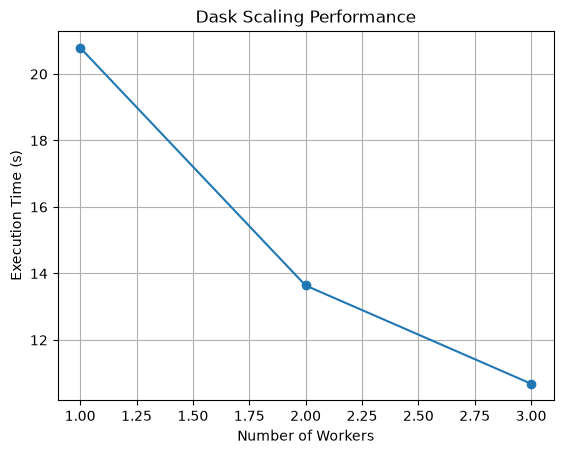

In [12]:
import matplotlib.pyplot as plt

# benchmark comparison
plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.xticks(rotation=45)
plt.ylabel("Execution Time (s)")
plt.title("Dask Performance Benchmark")
plt.show()

# scaling plot
plt.figure()
plt.plot(list(scaling_results.keys()), list(scaling_results.values()), marker="o")
plt.xlabel("Number of Workers")
plt.ylabel("Execution Time (s)")
plt.title("Dask Scaling Performance")
plt.grid()
plt.show()

## Benchmark Interpretation

### Key observations:

- **Rolling computations** are significantly more expensive than baseline operations due to overlapping temporal windows, resulting in increased computational complexity and larger task graphs.
- **GroupBy operations** perform efficiently, as they naturally partition the data into independent subsets that can be processed in parallel.
- **Rechunking** introduces additional overhead due to data reorganization, which becomes more noticeable as dataset size increases.
- **Multi-variable processing** increases computational load and reflects realistic scientific workflows, where multiple datasets are analysed simultaneously.
- **Custom functions** illustrate the flexibility of Dask, enabling parallel execution of user-defined analytics across large datasets.
- **Persisting intermediate results** significantly improves performance for repeated computations by avoiding redundant data loading and recomputation.
- **Scaling the number of workers** reduces execution time, demonstrating effective parallelization, although improvements are not perfectly linear due to overhead and communication costs.

### Conclusion

Dask enables efficient and scalable processing of large Earth Observation datasets by:

- distributing computations across multiple workers
- operating on chunked, out-of-core data without loading entire datasets into memory
- using lazy evaluation to optimize execution workflows

The results show that Dask provides clear performance benefits for more complex and larger-scale workloads, making it well-suited for real-world geospatial data processing tasks.

## 8. Visualization
Plot aggregated time series

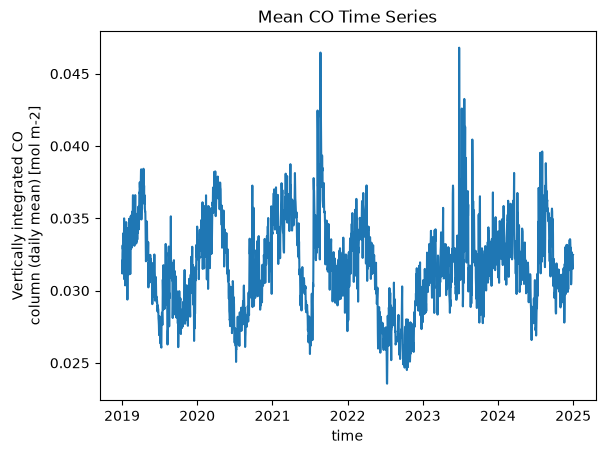

In [13]:
import matplotlib.pyplot as plt

result.plot()
plt.title('Mean CO Time Series')
plt.show()

## 9. Conclusions

- Dask enables lazy and parallel computation
- Zarr + STAC provides scalable cloud-native access
- Xarray simplifies multidimensional analysis
- Performance improves for large datasets due to parallel execution
